In [7]:
pip install pandas river scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.


In [9]:
import pandas as pd
from river import tree, metrics
from collections import Counter

# Load dataset
df = pd.read_csv("Downloads/project/data/ddos.csv.csv")

df.columns = df.columns.str.strip()
df = df.replace([float('inf'), -float('inf')], 0)
df = df.dropna()

# Label encoding
df['Label'] = df['Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)

# Sample
df = df.sample(50000)

# Keep numeric features
df = df.select_dtypes(include=['float64', 'int64'])

X = df.drop("Label", axis=1)
y = df["Label"]

# Ensemble of trees
n_trees = 5
models = [tree.HoeffdingTreeClassifier() for _ in range(n_trees)]

metric = metrics.Accuracy()
accuracies = []

# Stream learning
for i, (idx, row) in enumerate(X.iterrows()):
    x = row.to_dict()
    y_true = y.iloc[i]

    # 🔥 Get predictions from all trees
    votes = []

    for m in models:
        pred = m.predict_one(x)
        if pred is not None:
            votes.append(pred)

    # 🔥 Majority voting
    if votes:
        y_pred = Counter(votes).most_common(1)[0][0]
    else:
        y_pred = 0  # default prediction

    # Update metric
    metric.update(y_true, y_pred)

    # Train all trees
    for m in models:
        m.learn_one(x, y_true)

    # Log progress
    if i % 1000 == 0:
        acc = metric.get()
        accuracies.append(acc)
        print(f"Processed {i} samples → Accuracy: {acc:.4f}")

print("\nFinal Accuracy:", metric.get())

Processed 0 samples → Accuracy: 0.0000
Processed 1000 samples → Accuracy: 0.8422
Processed 2000 samples → Accuracy: 0.8631
Processed 3000 samples → Accuracy: 0.8780
Processed 4000 samples → Accuracy: 0.8765
Processed 5000 samples → Accuracy: 0.8868
Processed 6000 samples → Accuracy: 0.8922
Processed 7000 samples → Accuracy: 0.8986
Processed 8000 samples → Accuracy: 0.9066
Processed 9000 samples → Accuracy: 0.9109
Processed 10000 samples → Accuracy: 0.9142
Processed 11000 samples → Accuracy: 0.9166
Processed 12000 samples → Accuracy: 0.9189
Processed 13000 samples → Accuracy: 0.9218
Processed 14000 samples → Accuracy: 0.9254
Processed 15000 samples → Accuracy: 0.9286
Processed 16000 samples → Accuracy: 0.9325
Processed 17000 samples → Accuracy: 0.9362
Processed 18000 samples → Accuracy: 0.9391
Processed 19000 samples → Accuracy: 0.9418
Processed 20000 samples → Accuracy: 0.9445
Processed 21000 samples → Accuracy: 0.9469
Processed 22000 samples → Accuracy: 0.9490
Processed 23000 samples 

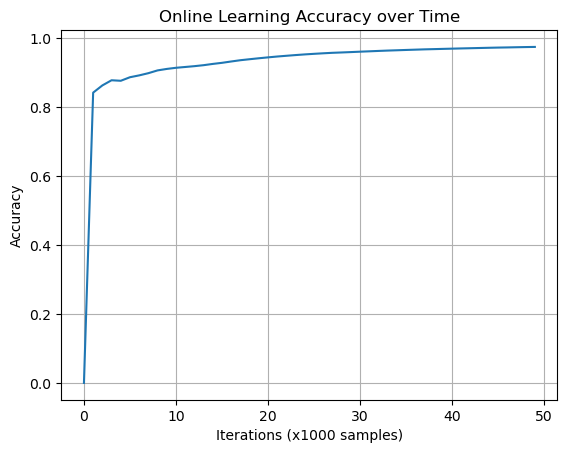

In [10]:
import matplotlib.pyplot as plt

plt.plot(accuracies)
plt.xlabel("Iterations (x1000 samples)")
plt.ylabel("Accuracy")
plt.title("Online Learning Accuracy over Time")
plt.grid()

plt.savefig("accuracy_graph.png")  # saves for report
plt.show()

0 → Acc: 0.0000 | Attacks: 0
1000 → Acc: 0.7972 | Attacks: 688
2000 → Acc: 0.8096 | Attacks: 1364
3000 → Acc: 0.8081 | Attacks: 2052
4000 → Acc: 0.8180 | Attacks: 2702
5000 → Acc: 0.8370 | Attacks: 3276
6000 → Acc: 0.8455 | Attacks: 3868
7000 → Acc: 0.8439 | Attacks: 4506
8000 → Acc: 0.8444 | Attacks: 5171
9000 → Acc: 0.8458 | Attacks: 5809
10000 → Acc: 0.8417 | Attacks: 6501
11000 → Acc: 0.8403 | Attacks: 7161
12000 → Acc: 0.8408 | Attacks: 7832
13000 → Acc: 0.8389 | Attacks: 8506
14000 → Acc: 0.8364 | Attacks: 9190
15000 → Acc: 0.8351 | Attacks: 9842
16000 → Acc: 0.8368 | Attacks: 10457
17000 → Acc: 0.8350 | Attacks: 11171
18000 → Acc: 0.8348 | Attacks: 11832
19000 → Acc: 0.8336 | Attacks: 12531
20000 → Acc: 0.8345 | Attacks: 13186
21000 → Acc: 0.8320 | Attacks: 13890
22000 → Acc: 0.8327 | Attacks: 14508
23000 → Acc: 0.8313 | Attacks: 15224
24000 → Acc: 0.8309 | Attacks: 15916
25000 → Acc: 0.8310 | Attacks: 16579
26000 → Acc: 0.8329 | Attacks: 17205
27000 → Acc: 0.8339 | Attacks: 178

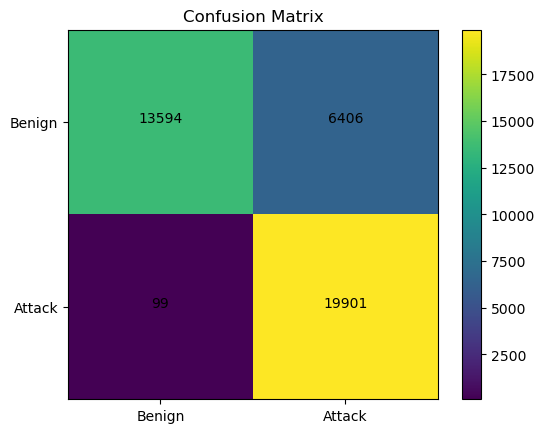

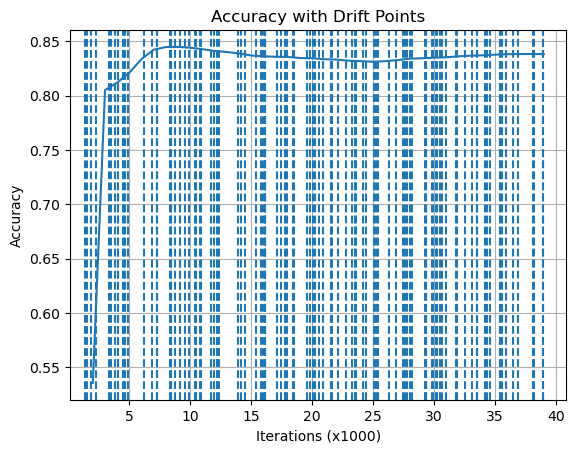

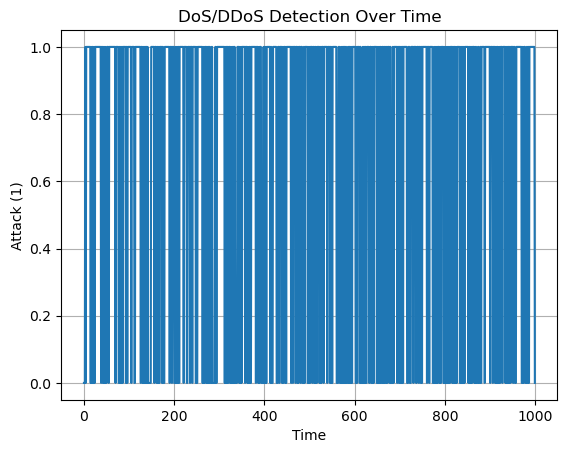

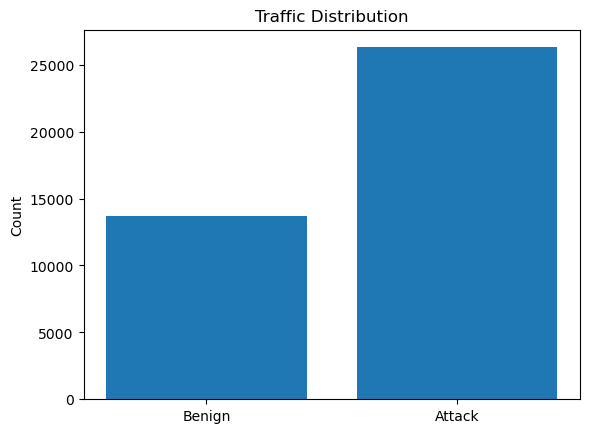

In [11]:
# ================================
# IMPORT LIBRARIES
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

from river import tree, metrics, drift


# ================================
# LOAD & BALANCE DATA
# ================================
df = pd.read_csv("Downloads/project/data/ddos.csv.csv")

df.columns = df.columns.str.strip()
df = df.replace([float('inf'), -float('inf')], 0)
df = df.dropna()

df['Label'] = df['Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)

# Balance dataset
benign = df[df['Label'] == 0].sample(20000, random_state=42)
attack = df[df['Label'] == 1].sample(20000, random_state=42)

df = pd.concat([benign, attack]).sample(frac=1, random_state=42)

df = df.select_dtypes(include=['float64', 'int64'])

X = df.drop("Label", axis=1)
y = df["Label"]

feature_names = list(X.columns)


# ================================
# ARF TREE CLASS
# ================================
class ARFTree:
    def __init__(self, features):
        self.model = tree.HoeffdingTreeClassifier()
        self.features = features

        self.correct = 0
        self.total = 0

        # tuned drift
        self.warning_detector = drift.ADWIN(delta=0.01)
        self.drift_detector = drift.ADWIN(delta=0.01)

        self.background_tree = None

    def predict(self, x):
        x_sub = {k: x[k] for k in self.features}
        return self.model.predict_one(x_sub)

    def learn(self, x, y):
        x_sub = {k: x[k] for k in self.features}
        self.model.learn_one(x_sub, y)

    def update_performance(self, y_true, y_pred):
        self.total += 1
        if y_true == y_pred:
            self.correct += 1

    def weight(self):
        return self.correct / self.total if self.total > 0 else 0.5


# ================================
# INITIALIZE FOREST
# ================================
n_trees = 10
m_features = int(np.sqrt(len(feature_names))) + 1

forest = [
    ARFTree(random.sample(feature_names, m_features))
    for _ in range(n_trees)
]

metric = metrics.Accuracy()

accuracies = []
detections = []
drift_points = []

attack_count = 0

tp = tn = fp = fn = 0


# ================================
# STREAM LEARNING
# ================================
for i, (idx, row) in enumerate(X.iterrows()):
    x = row.to_dict()
    y_true = y.iloc[i]

    # voting
    votes = {0: 0, 1: 0}

    for t in forest:
        pred = t.predict(x)
        w = t.weight()

        if pred is None:
            pred = 0

        votes[pred] += w

    # improved decision
    total_votes = votes[0] + votes[1]

    if total_votes == 0:
        y_pred = 0
    elif votes[1] / total_votes > 0.6:
        y_pred = 1
    else:
        y_pred = 0

    metric.update(y_true, y_pred)

    # confusion matrix
    if y_true == 1 and y_pred == 1:
        tp += 1
    elif y_true == 0 and y_pred == 0:
        tn += 1
    elif y_true == 0 and y_pred == 1:
        fp += 1
    elif y_true == 1 and y_pred == 0:
        fn += 1

    # update trees
    for t in forest:
        pred = t.predict(x)

        if pred is None:
            pred = 0

        t.update_performance(y_true, pred)

        error = 0 if pred == y_true else 1

        t.warning_detector.update(error)
        if t.warning_detector.drift_detected and t.background_tree is None:
            t.background_tree = ARFTree(t.features)

        t.drift_detector.update(error)
        if t.drift_detector.drift_detected:
            drift_points.append(i)

            if t.background_tree:
                t.model = t.background_tree.model
                t.background_tree = None
            else:
                t.model = tree.HoeffdingTreeClassifier()

            t.warning_detector = drift.ADWIN(delta=0.01)
            t.drift_detector = drift.ADWIN(delta=0.01)

        k = np.random.poisson(1)
        for _ in range(k):
            t.learn(x, y_true)

        if t.background_tree:
            t.background_tree.learn(x, y_true)

    if y_pred == 1:
        detections.append(1)
        attack_count += 1
    else:
        detections.append(0)

    if i % 1000 == 0:
        acc = metric.get()
        accuracies.append(acc)
        print(f"{i} → Acc: {acc:.4f} | Attacks: {attack_count}")


# ================================
# RESULTS
# ================================
print("\nFinal Accuracy:", metric.get())

precision = tp / (tp + fp)
recall = tp / (tp + fn)

print("Precision:", precision)
print("Recall:", recall)

print(f"\nTP: {tp} TN: {tn} FP: {fp} FN: {fn}")


# ================================
# CONFUSION MATRIX
# ================================
cm = np.array([[tn, fp],[fn, tp]])

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xticks([0,1],["Benign","Attack"])
plt.yticks([0,1],["Benign","Attack"])

for i in range(2):
    for j in range(2):
        plt.text(j,i,cm[i,j],ha="center")

plt.colorbar()
plt.show()


# ================================
# ACCURACY GRAPH
# ================================
smooth_acc = pd.Series(accuracies).rolling(3).mean()
plt.figure()
plt.plot(smooth_acc)
for d in drift_points:
    plt.axvline(x=d/1000, linestyle='--')
plt.title("Accuracy with Drift Points")
plt.xlabel("Iterations (x1000)")
plt.ylabel("Accuracy")
plt.grid()
plt.show()


# ================================
# DETECTION GRAPH
# ================================
plt.figure()
plt.plot(detections[:1000])
plt.title("DoS/DDoS Detection Over Time")
plt.xlabel("Time")
plt.ylabel("Attack (1)")
plt.grid()
plt.show()

# ================================
# TRAFFIC DISTRIBUTION
# ================================
labels = ["Benign", "Attack"]
values = [tn + fn, tp + fp]
plt.figure()
plt.bar(labels, values)
plt.title("Traffic Distribution")
plt.ylabel("Count")
plt.show()